In [3]:
import pandas as pd  #loading data
import numpy as np  #mathematical calculations
import re  #Regular expression for cleaning data
import nltk  #for basics
import matplotlib.pyplot as plt  #visualizations
from nltk.corpus import stopwords  #to remove be verbs unwanted words
from nltk.tokenize import word_tokenize  #splitting the words into units
from nltk.sentiment import SentimentIntensityAnalyzer  #to give score on the basis of the sentence given
from collections import Counter  #to count the frequency of elements (like words) and find how many times each item appears in data.
from wordcloud import WordCloud  #visualize the most frequently occurring words in text data, where larger words represent higher frequency.

#download required NLTK files
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

#display first few rows
print("Customer reviews dataset")
print(df.head)



Customer reviews dataset
<bound method NDFrame.head of                                               Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.
5      Poor quality product and terrible experience.
6                  Fast shipping and good packaging.
7        The product stopped working after two days.
8               Excellent service and great quality.
9            Late delivery and bad customer support.>


In [9]:

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # convert to lowercase
    text = text.lower()
    print('lower case:', text)

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print('special character:', text)

    # tokenization
    words = word_tokenize(text)
    print('tokenization:', words)

    # remove stopwords
    words = [word for word in words if word not in stop_words]
    print('stopwords:', words)

    # join words again
    cleaned_text = " ".join(words)

    return cleaned_text


# Apply cleaning function
df['cleaned_review'] = df['Review'].apply(clean_text)

print("\nCleaned Reviews")
print(df[['Review', 'cleaned_review']])

lower case: the product quality is excellent and delivery was very fast.
special character: the product quality is excellent and delivery was very fast
tokenization: ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords: ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case: very bad packaging and the item was damaged.
special character: very bad packaging and the item was damaged
tokenization: ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords: ['bad', 'packaging', 'item', 'damaged']
lower case: customer service was helpful and responsive.
special character: customer service was helpful and responsive
tokenization: ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords: ['customer', 'service', 'helpful', 'responsive']
lower case: the delivery was delayed and support team did not respond.
special character: the delivery was delayed and support team did not respond
tokenization: ['t

In [11]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):
    score = sia.polarity_scores(review)
    compound = score['compound']

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"


# Apply sentiment analysis
df['Sentiment'] = df['cleaned_review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['Review', 'Sentiment']])


Sentiment Analysis Results
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [12]:
all_words = " ".join(df['cleaned_review'])
word_list = all_words.split()

#count word frequency
word_freq = Counter(word_list)

#Display top 10 keywords
print("\nTop 10 Keywords")
print(word_freq.most_common(10))


Top 10 Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [13]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['cleaned_review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)
print("\nMost commonn complaint keywords")
print(complaint_freq.most_common(10))



Most commonn complaint keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


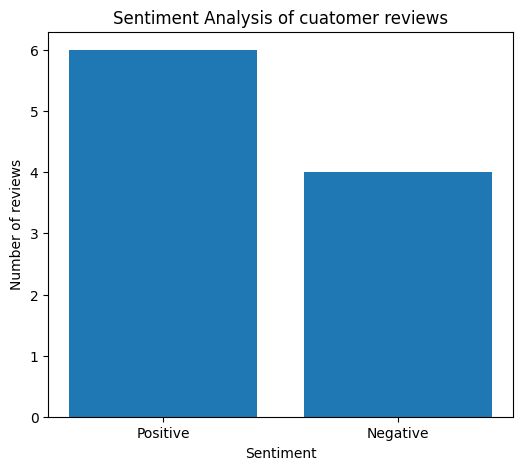

In [15]:
sentiment_counts = df['Sentiment'].value_counts()  #it will give categories count
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.title('Sentiment Analysis of cuatomer reviews')
plt.show()

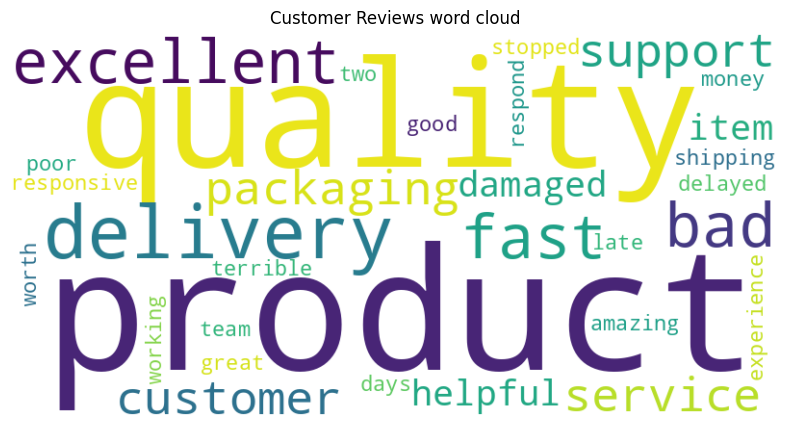

In [16]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Customer Reviews word cloud')
plt.show()